Heart Disease — классификация

**Цель:** на реальном медицинском датасете сравнить несколько алгоритмов классификации и проанализировать их поведение.

**Задача:** предсказать наличие сердечного заболевания  
`target = 1` — заболевание есть  
`target = 0` — заболевания нет  

---

## 1) Первичный анализ данных

Используя стандартные инструменты (`pandas`, `matplotlib`, `seaborn`), проведите анализ данных и сделайте выводы.

### 1.1 Общая структура
- Опишите размер датасета  
- Определите типы признаков  
- Проверьте наличие пропусков  

Выводы: какие признаки числовые, есть ли категориальные, есть ли проблемы в данных?

---

### 1.2 Целевая переменная
- Посчитайте количество объектов каждого класса  
- Определите, есть ли дисбаланс  

Выводы: можно ли в этой задаче ориентироваться только на accuracy?

---

### 1.3 Анализ признаков
Выберите 2–3 признака и:
- постройте графики распределения  
- сравните их поведение для классов 0 и 1  

Сделайте вывод: есть ли признаки, которые визуально разделяют классы?

---

## 2) Подготовка данных

### 2.1 Разбиение 
- Разбейте данные на train/test (`test_size=0.2`, `random_state=42`)  
- Используйте `stratify=y`  
- Кратко объясните, зачем тут может быть нужна стратификация

---

### 2.2 Подготовка признаков
- Если есть категориальные признаки — закодируйте их  
- Масштабируйте числовые признаки (`StandardScaler`)  

Объясните (2–3 строки), зачем масштабирование важно для некоторых моделей.

---

## 3) Обучение моделей и подбор гиперпараметров

Обучите три модели. Для каждой попробуйте подобрать **основные гиперпараметры** и сравните результаты.

### 3.1 Logistic Regression
Попробуйте разные значения:
- `C` (например: 0.01, 0.1, 1, 10)
- при желании — `class_weight`

Определите, какое значение даёт лучший результат.

---

### 3.2 kNN
Попробуйте разные значения:
- `n_neighbors` (например: 3, 5, 7, 11)

Проанализируйте, как меняются метрики при увеличении k.

---

### 3.3 Decision Tree
Попробуйте разные значения:
- `max_depth` (например: 3, 5, 7, None)
- при желании — `min_samples_leaf`

Посмотрите, как глубина влияет на качество.

---

### 3.4 Оценка качества
Для каждой лучшей версии модели на test посчитайте:
- `accuracy`  
- `precision`  
- `recall`  
- `f1`  

Сведите итоговые результаты в таблицу и кратко прокомментируйте различия.

---

## 4) Анализ результатов

Сделайте одну визуализацию:
- либо confusion matrix для лучшей модели  
- либо график сравнения метрик моделей  

Ответьте письменно (5–7 строк):
- Какая модель показала лучший результат?
- Где наблюдается конфликт между precision и recall?
- Почему нельзя смотреть только на accuracy?

In [1]:
from sklearn.datasets import fetch_openml

data = fetch_openml(name="heart-disease", as_frame=True)


df = data.frame
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,3.0,145.0,233.0,1.0,0.0,150.0,0.0,2.3,0.0,0.0,1.0,1.0
1,37.0,1.0,2.0,130.0,250.0,0.0,1.0,187.0,0.0,3.5,0.0,0.0,2.0,1.0
2,41.0,0.0,1.0,130.0,204.0,0.0,0.0,172.0,0.0,1.4,2.0,0.0,2.0,1.0
3,56.0,1.0,1.0,120.0,236.0,0.0,1.0,178.0,0.0,0.8,2.0,0.0,2.0,1.0
4,57.0,0.0,0.0,120.0,354.0,0.0,1.0,163.0,1.0,0.6,2.0,0.0,2.0,1.0


## 1) Первичный анализ данных

### 1.1 Общая структура 

In [2]:
df.shape

(303, 14)

Опишите размер датасета: 303 - строк, 14 - столбцов

In [3]:
df.dtypes

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target      float64
dtype: object

Определите типы признаков: все признаки имеют тип данных float64

Определим категориальные и непрерывные признаки:

In [4]:
print(df.nunique())

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64


Видно, что target, thal, ca, slope, exang, restecg, fbs, cp, sex - категориальные признаки, т.к. имеют не больше 5 уникалных значений.

Остальные признаки непрерывные: age, trestbps, chol, thalach, oldpeak.    

In [5]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Проверьте наличие пропусков: в данных нет пропусков

Вывод: в данных 9 категориальных признаков и 5 непрерывных. В данных нет пропусков, поэтому в данных проблем нет. 

### 1.2 Целевая переменная

Посчитайте количество объектов каждого класса:

In [6]:
category = ['target', 'thal', 'ca', 'slope', 'exang', 'restecg', 'fbs', 'cp', 'sex']
counts_dict = {col: df[col].value_counts().to_dict() for col in category}
counts_dict

{'target': {1.0: 165, 0.0: 138},
 'thal': {2.0: 166, 3.0: 117, 1.0: 18, 0.0: 2},
 'ca': {0.0: 175, 1.0: 65, 2.0: 38, 3.0: 20, 4.0: 5},
 'slope': {2.0: 142, 1.0: 140, 0.0: 21},
 'exang': {0.0: 204, 1.0: 99},
 'restecg': {1.0: 152, 0.0: 147, 2.0: 4},
 'fbs': {0.0: 258, 1.0: 45},
 'cp': {0.0: 143, 2.0: 87, 1.0: 50, 3.0: 23},
 'sex': {1.0: 207, 0.0: 96}}

**Определите, есть ли дисбаланс**:

Сильный дисбаланс наблюдается у некоторых категориальных признаков, например у thal, так как большинство записей имеет значение 2 (166), а значение 0 встречается всего 2 раза. Похожая ситуация наблюдается у признаков ca и cp, где некоторые категории представлены значительно реже остальных.

У признака slope значения 2 и 1 имеют примерно одинаковое количество наблюдений (~140), а значение 0 встречается заметно реже (21). Аналогичная картина наблюдается у restecg.

Признак exang также имеет неравномерное распределение (0: 204, 1: 99).

В общем, у многих признаков присутствует неравномерность распределения категорий.

Однако целевая переменная target распределена достаточно равномерно (165 объектов класса 1 и 138 класса 0), поэтому выраженного дисбаланса классов в задаче классификации нет.

На **accuracy** нельзя полностью полагаться, потому что мы предсказываем показатель, связанный со здоровьем человека, и в такой задаче особенно важно учитывать типы ошибок. Некоторые категориальные признаки имеют редкие значения, из-за чего модель может хуже работать на таких подгруппах данных, даже если общая accuracy остаётся высокой. Однако целевая переменная распределена достаточно равномерно, поэтому accuracy всё же может использоваться как одна из метрик для оценки общей точности модели, но её следует рассматривать вместе с precision, recall и F1-score.

 ### 1.3 Анализ признаков

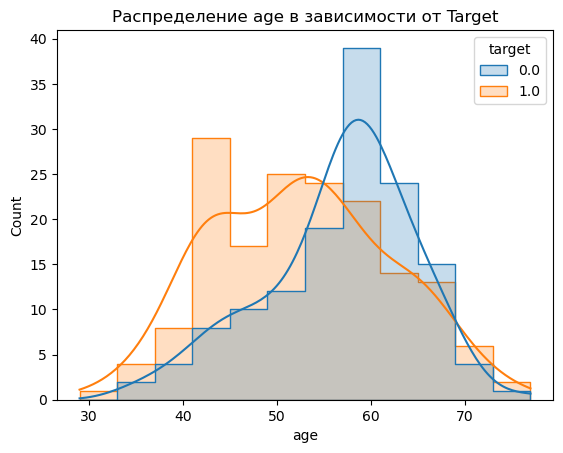

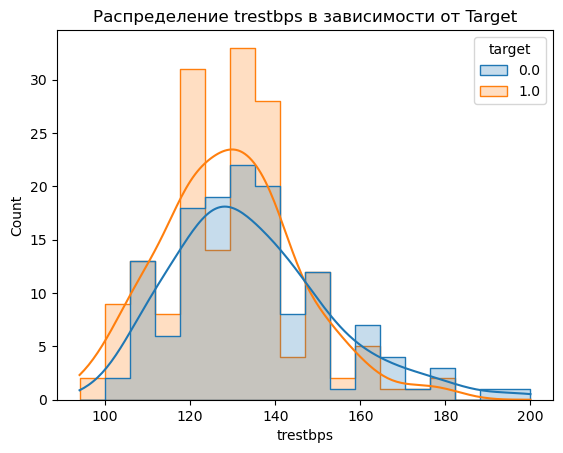

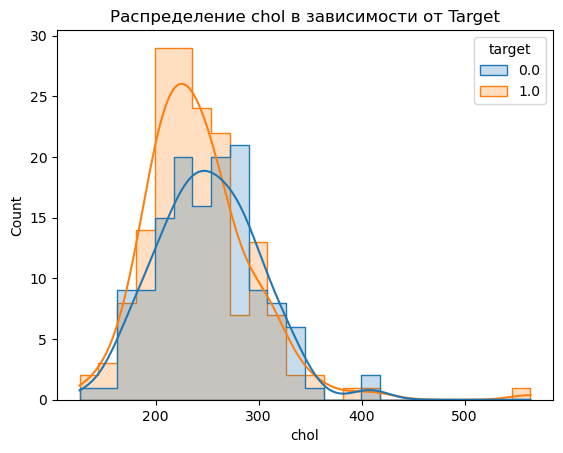

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['age', 'trestbps', 'chol']

for col in features:
    sns.histplot(data=df, x=col, hue='target', kde=True, element="step") # hue='target' — разбиваем по классам
    plt.title(f'Распределение {col} в зависимости от Target')
    plt.show()


По графику распределения возраста видно, что пациенты с заболеванием сердца (target = 1) чаще встречаются в более молодом возрасте - пик распределения приходится примерно на 40–50 лет.

В группе здоровых пациентов (target = 0) пик наблюдается в более старшем возрасте (около 55–65 лет).

Таким образом, возраст демонстрирует определённую связь с наличием заболевания и частично разделяет классы, однако распределения существенно перекрываются. Полученный результат выглядит несколько неожиданным, поскольку в общей популяции риск сердечно-сосудистых заболеваний обычно возрастает с возрастом.

В то же время признаки trestbps (артериальное давление в покое) и chol (уровень холестерина) демонстрируют значительное перекрытие распределений для обоих классов. Визуально они не обеспечивают явного разделения здоровых и больных пациентов.

## 2) Подготовка данных

### 2.1 Разбиение

In [8]:
from sklearn.model_selection import train_test_split

X = df.iloc[:, 0:13]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

С помощью функции train_test_split данные были разделены на обучающую и тестовую выборки. Поскольку целевая переменная (target) является категориальной и в данных возможен дисбаланс классов, используется параметр stratify=y. Это позволяет сохранить исходное соотношение классов в обучающей и тестовой выборках.

### 2.2 Подготовка признаков

In [9]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

category = ['thal', 'ca', 'slope', 'exang', 'restecg', 'fbs', 'cp', 'sex']
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), category), # кодируем категориальные признаки 
        ('num', StandardScaler(), num_cols) # Масштабируем числа
    ]
)

Масштабирование признаков важно при предобработке данных, потому что:
1) В моделях, где важна метрика, признаки с большим разбросом по значениям могут влиять больше на предсказание, даже если по факту менее важны.
2) При регуляризации признак, имеющий меньшее значение, но играющий важную роль в предсказание, будет иметь огромный вес, за что получит наказание при регуляризации. Это повлияет на вычисление предсказания.
3) При градиентном спуске при отсуствие масштабирования кривая плоскость может сильно деформироваться, что увеличит время нахождения минимума. При масштабирования плоскость становится более округлой и градиентный спуск можно выполнить за более короткое время. 

## 3) Обучение моделей и подбор гиперпараметров

### 3.1 Logistic Regression

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


log_reg = LogisticRegression(
    max_iter=1000, 
    class_weight='balanced'
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', log_reg)
])

param_grid = {'model__C': [0.01, 0.1, 1, 10, 100]}

grid_search_lr = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='f1'
)
grid_search_lr.fit(X_train, y_train)

print(f"Лучшее значение C: {grid_search_lr.best_params_['model__C']}")

best_model = grid_search_lr.best_estimator_
y_pred_log = best_model.predict(X_test)

print("\nОтчет по метрикам для лучшей LogReg:")
print(classification_report(y_test, y_pred_log))

D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Лучшее значение C: 10

Отчет по метрикам для лучшей LogReg:
              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82        28
         1.0       0.85      0.85      0.85        33

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


При исследовании гиперпараметра C с помощью GridSearchCV оптимальным оказалось значение 10. Это указывает на то, что для данной выборки предпочтительна относительно слабая регуляризация: более сильное ограничение коэффициентов ухудшало качество модели.

Высокие значения Precision и Recall для обоих классов показывают, что модель демонстрирует сбалансированное качество распознавания здоровых и больных пациентов. Использование class_weight='balanced' дополнительно способствует равномерному учету классов при обучении.

### 3.2 kNN

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

knn = KNeighborsClassifier()

pipeline_knn = Pipeline([
    ('preprocessor', preprocessor),
    ('model', knn)
])

param_grid = {'model__n_neighbors': [3, 5, 7, 11, 15, 21]}

grid_search = GridSearchCV(
    pipeline_knn, 
    param_grid, 
    cv=5, 
    scoring='f1'
)

grid_search.fit(X_train, y_train)

print(f"Лучшее количество соседей (k): {grid_search.best_params_['model__n_neighbors']}")

best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test)

print("\nОтчет по метрикам для лучшего kNN:")
print(classification_report(y_test, y_pred))

D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categ

Лучшее количество соседей (k): 7

Отчет по метрикам для лучшего kNN:
              precision    recall  f1-score   support

         0.0       0.77      0.71      0.74        28
         1.0       0.77      0.82      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


С помощью GridSearchCV было найдено оптимальное количество соседей 7. Это означает, что для данной выборки более устойчивый результат достигается при учёте нескольких ближайших соседей, а не слишком малого числа соседей.

Использование 7 соседей позволяет сгладить влияние отдельных выбросов и сделать предсказание более стабильным. Таким образом, модель ориентируется не на единичные объекты, а на общую структуру локального окружения точки.

### 3.3 Decision Tree (1 балл)

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

dt = DecisionTreeClassifier(
    class_weight='balanced', 
    random_state=42
)

pipeline_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', dt)
])

param_grid = {
    'model__max_depth': [3, 5, 7, None],        
    'model__min_samples_leaf': [1, 2, 5, 10]    
}

grid_search_dt = GridSearchCV(
    pipeline_dt, 
    param_grid, 
    cv=5, 
    scoring='f1'
)
grid_search_dt.fit(X_train, y_train)

print(f"Лучшие параметры: {grid_search_dt.best_params_}")

best_dt = grid_search_dt.best_estimator_
y_pred = best_dt.predict(X_test)

print("\nОтчет по дереву решений:")
print(classification_report(y_test, y_pred))

D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categ

Лучшие параметры: {'model__max_depth': 3, 'model__min_samples_leaf': 10}

Отчет по дереву решений:
              precision    recall  f1-score   support

         0.0       0.71      0.54      0.61        28
         1.0       0.68      0.82      0.74        33

    accuracy                           0.69        61
   macro avg       0.69      0.68      0.68        61
weighted avg       0.69      0.69      0.68        61



D:\Programs\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


При подборе гиперпараметров дерева решений оптимальными оказались глубина 3 и минимальное количество объектов в листе 10. Небольшая глубина дерева указывает на то, что более сложные разбиения не улучшали качество модели, а более глубокие деревья, вероятно, приводили к переобучению.

Параметр min_samples_leaf = 10 дополнительно ограничивает сложность модели и делает её более устойчивой к случайным колебаниям данных.

Метрики качества показывают, что модель уступает логистической регрессии: F1 для здоровых пациентов составляет около 0.61, а для пациентов с заболеванием — около 0.74. Это означает, что дерево хуже разделяет классы по сравнению с другими моделями.

Использование class_weight='balanced' способствует более внимательному учету класса заболевания, что отражается в относительно высоком recall для больных пациентов. Однако при этом точность определения здоровых пациентов оказывается ниже.

### 3.4 Оценка качества 

| Модель | Параметры | Accuracy | Precision (1.0) | Recall (1.0) | F1-score (1.0) |
| :--- | :--- | :---: | :---: | :---: | :---: |
| **Logistic Regression** | `C: 10` | **0.84** | **0.85** | **0.85** | **0.85** |
| **k-Nearest Neighbors** | `k: 7` | 0.77 | 0.77 | 0.82 | 0.79 |
| **Decision Tree** | `depth: 3, leaf: 10` | 0.69 | 0.68 | 0.82 | 0.74 |

По сравнительной таблице видно, что Logistic Regression показывает наилучшее качество предсказания наличия заболевания. Это может свидетельствовать о том, что структура данных достаточно хорошо описывается линейной моделью и не требует сложных нелинейных разбиений. Относительно слабая регуляризация (C = 10) позволила подобрать веса, обеспечивающие хороший баланс между точностью и полнотой.KNN справляется хуже, но всё же лучше, чем Decision Tree. Decision Tree лучше определяет больных пациентов (высокий recall), однако чаще относит здоровых к больным, что связано со смещением модели в сторону класса заболевания при использовании class_weight='balanced'.

## 4) Анализ результатов

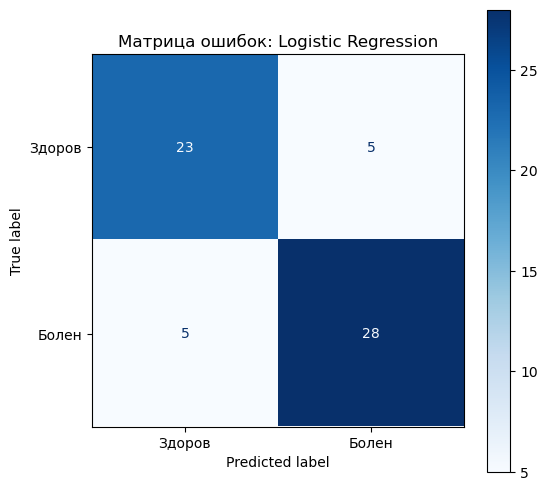

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Здоров', 'Болен']
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Матрица ошибок: Logistic Regression')
plt.show()


По confusion matrix видно, что модель сделала правильно 51 предсказание, и в 10 случаях ошиблась, критичны из которых 5, т.к. она обозначила больных за здоровых.

Лучший результат показывает Logistic Regression (F1 = 0.85), что свидетельствует о более эффективном разделении классов. У Decision Tree наблюдается выраженный конфликт между precision и recall: высокий recall (0.82) достигается за счёт снижения точности (0.68), поскольку модель чаще предсказывает наличие заболевания. Опираться только на accuracy нельзя, так как в медицинских задачах цена ошибок различна: пропуск болезни значительно опаснее, чем общий процент правильных предсказаний.